# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

# TODO: assert unique row_id values and exact alignment of feature columns.
print(train.shape, val_obs.shape, val_ref.shape, test_obs.shape, test_ref.shape)

(18000, 15) (6000, 15) (6000, 16) (6000, 15) (6000, 16)


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

In [8]:
print(f"Training columns: {train.columns}")
print(f"Validation observed columns: {val_obs.columns}")
print(f"Validation reference columns: {val_ref.columns}")
print(f"Test observed columns: {test_obs.columns}")
print(f"Test reference columns: {test_ref.columns}")

Training columns: Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH',
       'income_observed'],
      dtype='str')
Validation observed columns: Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH',
       'income_observed'],
      dtype='str')
Validation reference columns: Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH',
       'income_observed', 'income_reference'],
      dtype='str')
Test observed columns: Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX', 'RAC1P', 'SEX_group', 'RACE_group', 'SURVEY_BATCH',
       'income_observed'],
      dtype='str')
Test reference columns: Index(['row_id', 'AGEP', 'COW', 'SCHL', 'MAR', 'OCCP', 'POBP', 'RELP', 'WKHP',
       'SEX',

In [10]:
# TODO: join observed and reference files by row_id.


# TODO: quantify and visualize label disagreement.
val_disagree = val_ref[val_ref["income_observed"] != val_ref["income_reference"]]
test_disagree = test_ref[test_ref["income_observed"] != test_ref["income_reference"]]

print(f"Validation: {len(val_disagree)} disagreements out of {len(val_ref)} ({len(val_disagree) / len(val_ref):.1%})")
display(val_disagree)

print(f"Test: {len(test_disagree)} disagreements out of {len(test_ref)} ({len(test_disagree) / len(test_ref):.1%})")
display(test_disagree)

# TODO: test the Week 2 hypotheses without reading the new metadata.

Validation: 242 disagreements out of 6000 (4.0%)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed,income_reference
39,18039,32.0,1.0,22.0,1.0,440.0,210.0,1.0,40.0,2.0,6.0,Female,Asian,B03,0,1
44,18044,43.0,4.0,21.0,1.0,3402.0,48.0,1.0,80.0,1.0,1.0,Male,White,B03,1,0
79,18079,66.0,3.0,22.0,1.0,2310.0,48.0,1.0,16.0,2.0,2.0,Female,Black,B06,0,1
90,18090,47.0,3.0,22.0,1.0,230.0,48.0,1.0,40.0,2.0,1.0,Female,White,B05,0,1
136,18136,65.0,1.0,19.0,1.0,10.0,48.0,0.0,45.0,2.0,1.0,Female,White,B08,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5872,23872,61.0,2.0,16.0,1.0,9130.0,6.0,1.0,56.0,1.0,1.0,Male,White,B07,0,1
5889,23889,34.0,1.0,11.0,3.0,6230.0,303.0,0.0,48.0,1.0,1.0,Male,White,B04,1,0
5900,23900,47.0,1.0,21.0,3.0,5740.0,48.0,0.0,40.0,2.0,1.0,Female,White,B06,0,1
5948,23948,37.0,1.0,19.0,1.0,3603.0,233.0,1.0,54.0,2.0,6.0,Female,Asian,B07,0,1


Test: 249 disagreements out of 6000 (4.2%)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed,income_reference
21,24021,35.0,1.0,16.0,1.0,8225.0,48.0,1.0,99.0,1.0,1.0,Male,White,B01,0,1
83,24083,42.0,1.0,22.0,3.0,800.0,12.0,0.0,40.0,2.0,1.0,Female,White,B04,0,1
126,24126,25.0,2.0,21.0,5.0,3255.0,48.0,0.0,38.0,1.0,1.0,Male,White,B07,0,1
128,24128,31.0,1.0,21.0,1.0,410.0,48.0,0.0,50.0,2.0,1.0,Female,White,B03,0,1
136,24136,28.0,1.0,22.0,5.0,800.0,22.0,0.0,40.0,1.0,6.0,Male,Asian,B02,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5893,29893,58.0,1.0,17.0,1.0,20.0,303.0,1.0,40.0,2.0,1.0,Female,White,B06,0,1
5899,29899,49.0,1.0,9.0,1.0,4230.0,303.0,1.0,45.0,2.0,1.0,Female,White,B01,1,0
5926,29926,59.0,1.0,1.0,1.0,10.0,303.0,0.0,40.0,1.0,1.0,Male,White,B01,0,1
5940,29940,39.0,2.0,22.0,3.0,60.0,53.0,0.0,45.0,2.0,1.0,Female,White,B06,0,1


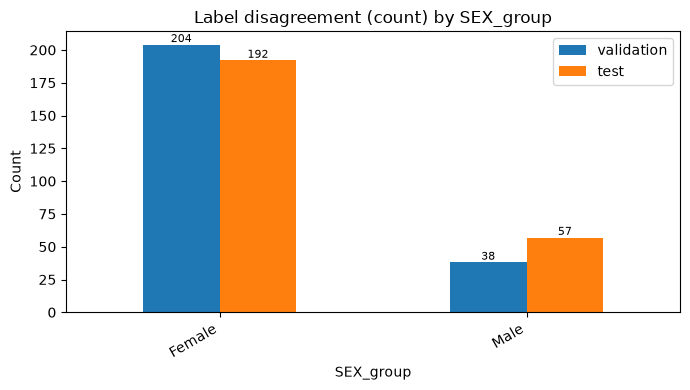

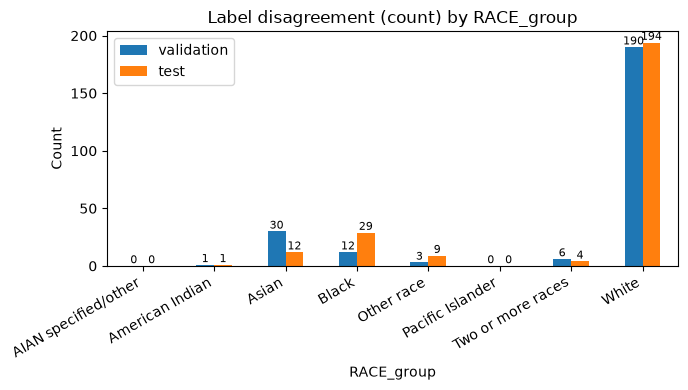

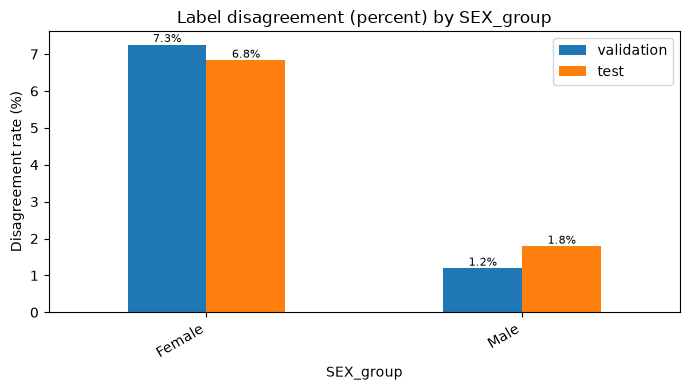

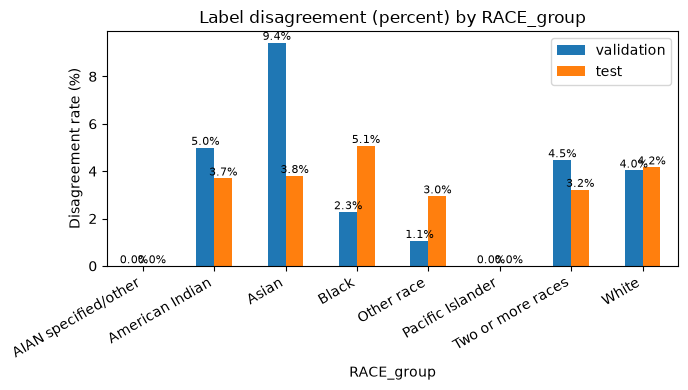

,validation,test
RACE_group,,
AIAN specified/other,0.000000,0.000000
American Indian,5.000000,3.703704
Asian,9.433962,3.809524
Black,2.281369,5.078809
Other race,1.067616,2.950820
Pacific Islander,0.000000,0.000000
Two or more races,4.477612,3.225806
White,4.039974,4.174736


In [30]:
def compare_disagreement(val_df, test_df, group_col, mode="percent"):
    def agg(df):
        grouped = df.groupby(group_col)
        if mode == "count":
            return grouped.apply(lambda g: (g["income_observed"] != g["income_reference"]).sum())
        return grouped.apply(lambda g: (g["income_observed"] != g["income_reference"]).mean() * 100)

    values = pd.DataFrame({"validation": agg(val_df), "test": agg(test_df)})

    fmt = "%.0f" if mode == "count" else "%.1f%%"
    ax = values.plot(kind="bar", figsize=(7, 4), title=f"Label disagreement ({mode}) by {group_col}")
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, fontsize=8)
    ax.set_ylabel("Count" if mode == "count" else "Disagreement rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    return values


#Count
compare_disagreement(val_ref, test_ref, "SEX_group", mode="count")
compare_disagreement(val_ref, test_ref, "RACE_group", mode="count")

#Percent
compare_disagreement(val_ref, test_ref, "SEX_group", mode="percent")
compare_disagreement(val_ref, test_ref, "RACE_group", mode="percent")

Look at the swings again: Asian goes 9.4% → 3.8% (more than halves), Black goes 2.3% → 5.1% (more than doubles), Other race goes 1.1% → 3.0% (triples), and two categories (AIAN specified/other, Pacific Islander) show a flat 0.0%/0.0%. Compare that to White: 4.0% → 4.2% — barely moves at all, and sits right at the overall dataset average (~4.0%/4.2% you reported earlier).

That pattern — the biggest, most numerous category tracking the overall average almost exactly, while several other categories swing wildly between two random samples of the same population — is the signature of small subgroup sample sizes, not a real group-specific effect. With few people in a category (say, 50–150), a handful of extra disagreements by chance can double or triple the percentage; a 0.0% for a tiny group could just mean "we happened to get zero disagreements in that handful of rows," not "this group is truly immune." SEX_group, by contrast, is presumably split close to 50/50 in a dataset this size, so both its rate estimates rest on thousands of rows each — which is exactly why it stayed stable (7.3/6.8, 1.2/1.8) while RACE_group's smaller categories didn't.

# Audit report from week 2

Functions from week 2

In [21]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss,
    confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import MetricFrame, selection_rate, count

def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


def expected_calibration_error(table):
    total = table["count"].sum()
    return float((table["count"] / total * table["gap"]).sum())

def calibration_table(y_true, y_proba, n_bins=10, min_bin_size=30):
    data = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    data["bin"] = pd.qcut(data["y_proba"], q=n_bins, duplicates="drop")
    table = data.groupby("bin", observed=True).agg(
        mean_predicted=("y_proba", "mean"),
        observed_rate=("y_true", "mean"),
        count=("y_true", "size"),
    ).reset_index()
    table["gap"] = (table["mean_predicted"] - table["observed_rate"]).abs()
    table["reliable"] = table["count"] >= min_bin_size
    return table

def calibration_table_fixed_bins(y_true, y_proba, bin_edges, min_bin_size=30):
    data = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
    data["bin"] = pd.cut(data["y_proba"], bins=bin_edges, include_lowest=True)
    table = data.groupby("bin", observed=True).agg(
        mean_predicted=("y_proba", "mean"),
        observed_rate=("y_true", "mean"),
        count=("y_true", "size"),
    ).reset_index()
    table["gap"] = (table["mean_predicted"] - table["observed_rate"]).abs()
    table["reliable"] = table["count"] >= min_bin_size
    return table

def reliability_plot(y_true, y_proba, group=None, n_bins=10, title=""):
    _, bin_edges = pd.qcut(y_proba, q=n_bins, duplicates="drop", retbins=True)  # shared edges, computed once on everyone

    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")

    groups = {"all": pd.Series(True, index=y_true.index)} if group is None else {g: (group == g) for g in sorted(group.unique())}
    for name, mask in groups.items():
        table = calibration_table_fixed_bins(y_true[mask], y_proba[mask], bin_edges)
        table = table[table["count"] > 0]  # a shared bin can still be empty for one group
        plt.plot(table["mean_predicted"], table["observed_rate"], marker="o", label=name)
        ece = expected_calibration_error(table)
        brier = brier_score_loss(y_true[mask], y_proba[mask])
        print(f"{name}: ECE={ece:.3f}, Brier={brier:.3f}, n={mask.sum()}")

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency of label = 1")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


UTILITY_METRICS = {"count": count, "accuracy": accuracy_score, "balanced_accuracy": balanced_accuracy_score}
INDEPENDENCE_METRICS = {"selection_rate": selection_rate}     # equal selection rate across groups
SEPARATION_METRICS = {"tpr": true_positive_rate, "fpr": false_positive_rate}  # equal error rates given true label
SUFFICIENCY_METRICS = {"ppv": positive_predictive_value, "npv": negative_predictive_value}  # equal outcome given prediction

def audit_report(y_eval, scores, predictions, sensitive_series, title=""):
    metrics = {**UTILITY_METRICS, **INDEPENDENCE_METRICS, **SEPARATION_METRICS, **SUFFICIENCY_METRICS}
    mf = MetricFrame(metrics=metrics, y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_series)

    print(f"\n===== {title} =====")
    print("\nBy group:")
    display(mf.by_group.round(3))
    print("\nOverall:")
    display(mf.overall.round(3).to_frame("value"))

    gaps = mf.difference(method="between_groups")
    print("\nFairness gaps (max - min across groups):")
    for name in ["selection_rate", "tpr", "fpr", "ppv", "npv"]:
        print(f"  {name}: {gaps[name]:.3f}")

    print("\nCalibration by group:")
    reliability_plot(y_eval, scores, group=sensitive_series, title=f"{title} — calibration")

    return mf



#  Week 3 task start

Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [ ]:
# TODO: reconstruct your Week 2 baseline.
# TODO: create a reusable audit function accepting y_eval, scores, predictions, and sensitive features.
# TODO: report utility, independence, separation, sufficiency, and calibration twice.

I am excluding race in the training because i want to focus solely on sex and i think the race is also a sensitive .

In [22]:


LABEL = "income_observed"
ID = "row_id"
SENSITIVE = "SEX_group"

NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]  # RACE/SEX excluded: sensitive attributes
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_model(frame):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])
    return Pipeline([
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ])

model = make_model(train)
model.fit(train[FEATURE_COLUMNS], train[LABEL])  # fit on observed training labels only -- never on income_reference

val_pred = model.predict(val_ref[FEATURE_COLUMNS])
val_proba = model.predict_proba(val_ref[FEATURE_COLUMNS])[:, 1]



===== Audit vs. income_observed =====

By group:


,count,accuracy,balanced_accuracy,selection_rate,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,2812.0,0.791,0.692,0.217,0.516,0.131,0.529,0.863
Male,3188.0,0.782,0.769,0.366,0.671,0.133,0.795,0.775



Overall:


,value
count,6000.000
accuracy,0.786
balanced_accuracy,0.746
selection_rate,0.296
tpr,0.623
fpr,0.132
ppv,0.703
npv,0.821



Fairness gaps (max - min across groups):
  selection_rate: 0.150
  tpr: 0.155
  fpr: 0.002
  ppv: 0.266
  npv: 0.088

Calibration by group:
Female: ECE=0.060, Brier=0.140, n=2812
Male: ECE=0.050, Brier=0.152, n=3188


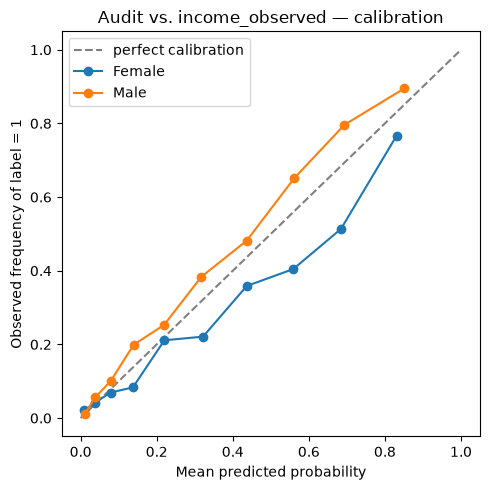


===== Audit vs. income_reference =====

By group:


,count,accuracy,balanced_accuracy,selection_rate,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,2812.0,0.814,0.735,0.217,0.554,0.084,0.722,0.839
Male,3188.0,0.783,0.770,0.366,0.671,0.130,0.801,0.773



Overall:


,value
count,6000.000
accuracy,0.798
balanced_accuracy,0.761
selection_rate,0.296
tpr,0.628
fpr,0.105
ppv,0.774
npv,0.807



Fairness gaps (max - min across groups):
  selection_rate: 0.150
  tpr: 0.117
  fpr: 0.046
  ppv: 0.078
  npv: 0.067

Calibration by group:
Female: ECE=0.028, Brier=0.130, n=2812
Male: ECE=0.054, Brier=0.151, n=3188


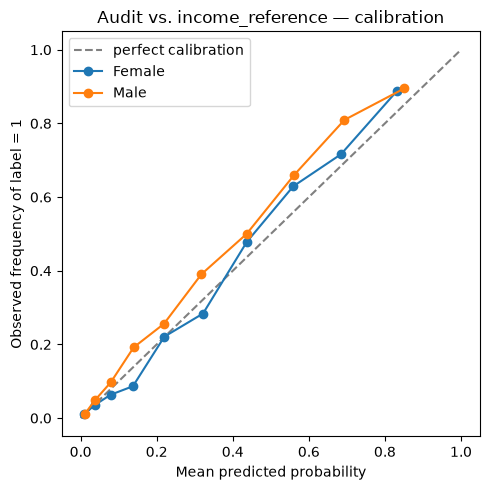

In [23]:
audit_obs = audit_report(val_ref[LABEL], val_proba, val_pred, val_ref[SENSITIVE], title="Audit vs. income_observed")
audit_ref = audit_report(val_ref["income_reference"], val_proba, val_pred, val_ref[SENSITIVE], title="Audit vs. income_reference")



AIAN specified/other: ECE=0.130, Brier=0.038, n=15
American Indian: ECE=0.230, Brier=0.139, n=20
Asian: ECE=0.056, Brier=0.153, n=318
Black: ECE=0.064, Brier=0.147, n=526
Other race: ECE=0.053, Brier=0.108, n=281
Pacific Islander: ECE=0.232, Brier=0.107, n=3
Two or more races: ECE=0.078, Brier=0.151, n=134
White: ECE=0.015, Brier=0.148, n=4703


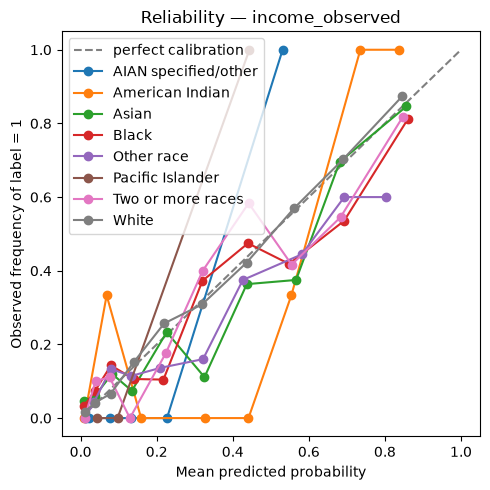

AIAN specified/other: ECE=0.130, Brier=0.038, n=15
American Indian: ECE=0.213, Brier=0.127, n=20
Asian: ECE=0.060, Brier=0.141, n=318
Black: ECE=0.060, Brier=0.149, n=526
Other race: ECE=0.046, Brier=0.106, n=281
Pacific Islander: ECE=0.232, Brier=0.107, n=3
Two or more races: ECE=0.063, Brier=0.143, n=134
White: ECE=0.041, Brier=0.142, n=4703


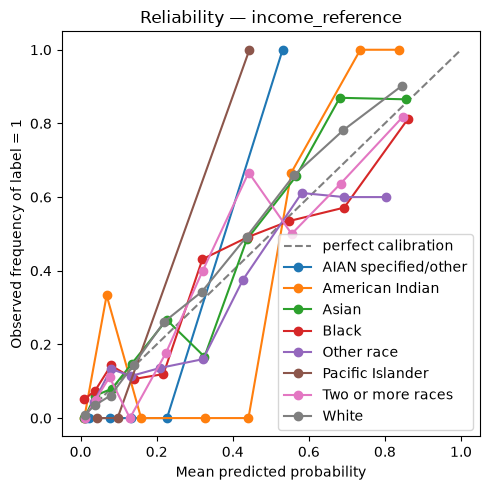

In [32]:
reliability_plot(val_ref[LABEL], val_proba, group=val_ref["RACE_group"], title="Reliability — income_observed")
reliability_plot(val_ref["income_reference"], val_proba, group=val_ref["RACE_group"], title="Reliability — income_reference")

all: ECE=0.011, Brier=0.146, n=6000


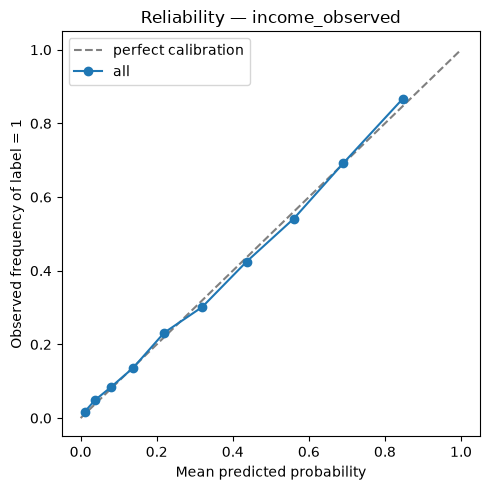

all: ECE=0.032, Brier=0.141, n=6000


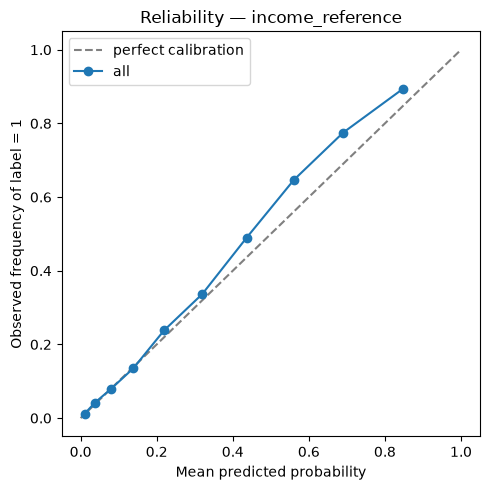

In [25]:
reliability_plot(val_ref[LABEL], val_proba, group=None, title="Reliability — income_observed")
reliability_plot(val_ref["income_reference"], val_proba, group=None, title="Reliability — income_reference")


HintL Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

In [ ]:
# TODO: define the candidates and a common experiment protocol.
# Keep preprocessing, split, random seed, and evaluation consistent.

Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression

# TODO: choose which validation label is appropriate for fitting a postprocessor.
# post = ThresholdOptimizer(estimator=base_model, constraints="equalized_odds", predict_method="predict_proba")
# post.fit(X_val, y_val_..., sensitive_features=A_val)

# TODO: implement, justify, and audit Fairlearn interventions.

Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Current sklearn pattern for a pre-fitted estimator. The calibration set
# must be disjoint from the model-fitting set:
# calibrated_obs = CalibratedClassifierCV(
#     estimator=FrozenEstimator(base_model), method="sigmoid"
# )
# calibrated_obs.fit(X_val, y_val_observed)

# TODO: implement all three pipelines, reliability plots, ECE, and log loss.

## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?